
Привет, меня зовут Люман Аблаев. Сегодня я проверю твой проект.
<br> Дальнейшее общение будет происходить на "ты" если это не вызывает никаких проблем.
<br> Желательно реагировать на красные комментарии ('исправил', 'не понятно как исправить ошибку', ...)
<br> Пожалуйста, не удаляй комментарии ревьюера, так как они повышают качество повторного ревью.

Комментарии будут в <font color='green'>зеленой</font>, <font color='blue'>синей</font> или <font color='red'>красной</font> рамках:


<div class="alert alert-block alert-success">
<b>Успех:</b> Если все сделано отлично
</div>

<div class="alert alert-block alert-info">
<b>Совет: </b> Если можно немного улучшить
</div>

<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Если требуются исправления. Работа не может быть принята с красными комментариями.
</div>

-------------------

Будет очень хорошо, если ты будешь помечать свои действия следующим образом:
<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> ...
</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Были внесены следующие изменения ...
</div>







<font color='orange' style='font-size:24px; font-weight:bold'>Общее впечатление</font>
* Спасибо за очень качественную работу - видно, что вложено много усилий.
- Я оставил некоторые советы, надеюсь они будут полезными и интересными
- Есть некоторые недочеты, которые нужно поправить, но у тебя это не должно занять много времени)
- Жду обновленную работу







# Анализ лояльности пользователей Яндекс Афиши

 <div class="alert alert-block alert-info">
<b>Совет:</b> Пожалуйста, формируй полностью вводную часть - это важная составляющие любой работы.  Нужны цели и задачи, описание данных, содержание проекта.
</div>

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [3]:
# Импорт библиотек для работы с данными и подключения к PostgreSQL
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus



<div class="alert alert-block alert-info">
<b>Совет:</b> Советую собирать все импорты в верхней части ноутбука! 
Если у того, кто будет запускать твой ноутбук будут отсутствовать некоторые библиотеки, то он это увидит сразу, а не в процессе!
</div>


In [4]:
import os
from dotenv import load_dotenv

# Загружаем переменные из .env файла
load_dotenv()

# Параметры подключения из переменных окружения
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PWD'),
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT')),
    'db': os.getenv('DB_NAME')
}

In [5]:
# Формирование строки подключения и создание движка
connection_string = (
    f"postgresql://{db_config['user']}:{quote_plus(db_config['pwd'])}"
    f"@{db_config['host']}:{db_config['port']}/{db_config['db']}"
)
engine = create_engine(connection_string)

In [6]:
# SQL-запрос для выгрузки всех необходимых полей
query = """
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    p.created_dt_msk::date - LAG(p.created_dt_msk::date) 
        OVER (PARTITION BY p.user_id 
              ORDER BY p.created_dt_msk) 
        AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    reg.region_name,
    ct.city_name
FROM afisha.purchases p
INNER JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city ct ON e.city_id = ct.city_id
LEFT JOIN afisha.regions reg ON ct.region_id = reg.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
    AND e.event_type_main != 'фильм'
"""

In [7]:
# Выполнение запроса и сохранение результата в датафрейм
df = pd.read_sql_query(query, con=engine)

In [8]:
# Первичный осмотр: первые строки и общая информация о данных
print("Первые 5 строк датафрейма:")
display(df.head())
print("\nИнформация о данных:")
print(df.info())

Первые 5 строк датафрейма:


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name          



<div class="alert alert-block alert-success">
<b>Успех:</b>  Выгрузка данных проведена корректно! Была выполнена необходимая фильтрация данных, выгружены только необходимые для анализа данные. Отлично, что сразу подсчитываешь время между заказами для каждого пользователя.
</div>
    
<div class="alert alert-block alert-info">
<b>Совет:</b> Можно немного улучшить запрос, добавив также и "ORDER BY user_id, order_dt". Так внутри каждого пользователя заказы будут идти строго по дате.
</div>


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

- Выгружено 290 611 заказов, полученных после SQL-фильтрации по типу устройства (`mobile`, `desktop`) и исключения фильмов.
- Пропуски присутствуют только в столбце `days_since_prev` (около 21 933), возможно это первые заказы пользователей.
- Типы данных: даты (`order_dt`, `order_ts`) распознаны как `datetime64`, числовые столбцы — `float64`/`int64`, категориальные — `object`. Для экономии памяти и ускорения дальнейшей работы категориальные поля можно привести к типу `category`.
- Выручка (`revenue`) представлена в двух валютах — `rub` и `kzt`, что потребует конвертации в рубли.
- Потенциальные выбросы в `revenue` и `tickets_count` будут проверены после конвертации в одну валюту, при необходимости применим фильтрацию по 99-му перцентилю.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [9]:
# Загрузка данных о курсе KZT/RUB за 2024 год
url_currency = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
currency_df = pd.read_csv(url_currency)

In [10]:
# Первичный просмотр загруженных курсов
print("Первые 5 строк курса:")
display(currency_df.head())
print("\nИнформация о датафрейме курса:")
print(currency_df.info())

Первые 5 строк курса:


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt



Информация о датафрейме курса:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB
None


In [11]:
# Преобразование столбца с датой в формат datetime для корректного объединения
currency_df['data'] = pd.to_datetime(currency_df['data'])

In [12]:
# Объединение основного датафрейма с курсом по дате заказа (order_dt)
df = df.merge(currency_df, left_on='order_dt', right_on='data', how='left')

In [13]:
# Расчёт выручки в рублях:
# для заказов в тенге (kzt) умножаем revenue на курс (curs) и делим на 100 (курс за 100 тенге)
# для заказов в рублях (rub) просто копируем revenue
df['revenue_rub'] = df.apply(
    lambda row: row['revenue'] * row['curs'] / row['nominal']
    if row['currency_code'] == 'kzt' else row['revenue'],
    axis=1
)

<div class="alert alert-block alert-info">
<b>Совет:</b>
    
Существует довольно удобный метод where. Мы можем применить его к столбцу и указать условие, которое будем проверять, а также альтернативный вариант значения. Если условие выполняется, то берется значение из столбца, если нет - альтернативное значение. Тогда расчет выручки в рублях будет выглядеть следующим образом:
    
```
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)
```
</div>



In [14]:
# Проверка результата: несколько строк с разными валютами
print("Пример строк с revenue и revenue_rub:")
display(df[['currency_code', 'revenue', 'curs', 'revenue_rub']].head(10))

Пример строк с revenue и revenue_rub:


,currency_code,revenue,curs,revenue_rub
0,rub,1521.94,18.6972,1521.94
1,rub,289.45,18.3419,289.45
2,rub,1258.57,19.6475,1258.57
3,rub,8.49,18.5010,8.49
4,rub,1390.41,19.6648,1390.41
5,rub,902.74,20.0531,902.74
6,rub,917.83,18.7730,917.83
7,rub,47.78,19.3741,47.78
8,rub,74.84,19.7185,74.84
9,rub,1421.91,18.0419,1421.91


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [15]:
# Проверка пропущенных значений во всех столбцах
print("Количество пропусков по столбцам:")
print(df.isnull().sum())

Количество пропусков по столбцам:
user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
data                         0
nominal                      0
curs                         0
cdx                          0
revenue_rub                  0
dtype: int64


In [16]:
# Анализ пропусков: days_since_prev должен содержать NaN для первых заказов
# Убедимся, что нет пропусков в других важных столбцах
nulls = df.isnull().sum()
print("Доля пропусков от общего числа строк:")
print(nulls[nulls > 0] / len(df) * 100)

Доля пропусков от общего числа строк:
days_since_prev    7.547202
dtype: float64


In [17]:
# Преобразуем типы данных для экономии памяти
# Столбцы с категориями — в тип category
cat_cols = ['device_type_canonical', 'currency_code', 'service_name', 
            'event_type_main', 'region_name', 'city_name']
for col in cat_cols:
    df[col] = df[col].astype('category')

# Проверим изменения
print("Типы данных после преобразования:")
print(df.dtypes)

Типы данных после преобразования:
user_id                          object
device_type_canonical          category
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                  category
revenue                         float64
tickets_count                     int64
days_since_prev                 float64
event_id                          int64
event_name                       object
event_type_main                category
service_name                   category
region_name                    category
city_name                      category
data                     datetime64[ns]
nominal                           int64
curs                            float64
cdx                              object
revenue_rub                     float64
dtype: object


In [18]:
# Проверка уникальных значений в категориальных столбцах на предмет аномалий
for col in cat_cols:
    print(f"Уникальные значения в {col}: {df[col].unique()[:20]}")
    print(f"Всего уникальных: {df[col].nunique()}\n")

Уникальные значения в device_type_canonical: ['mobile', 'desktop']
Categories (2, object): ['mobile', 'desktop']
Всего уникальных: 2

Уникальные значения в currency_code: ['rub', 'kzt']
Categories (2, object): ['rub', 'kzt']
Всего уникальных: 2

Уникальные значения в service_name: ['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!', 'Билеты без проблем', ..., 'Яблоко', 'Билет по телефону', 'Выступления.ру', 'Росбилет', 'Шоу начинается!']
Length: 20
Categories (36, object): ['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!', ..., 'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете']
Всего уникальных: 36

Уникальные значения в event_type_main: ['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Categories (7, object): ['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Всего уникальных: 7

Уникальные значения в region_name: ['Каменевский регион', 'Североярская область', 'Озернинский край', 'Лугоградская область', 'Поленовский край

In [19]:
# Базовая статистика для revenue_rub и tickets_count
print("Статистика по revenue_rub:")
display(df['revenue_rub'].describe())

print("\nСтатистика по tickets_count:")
display(df['tickets_count'].describe())

Статистика по revenue_rub:


count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64


Статистика по tickets_count:


count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

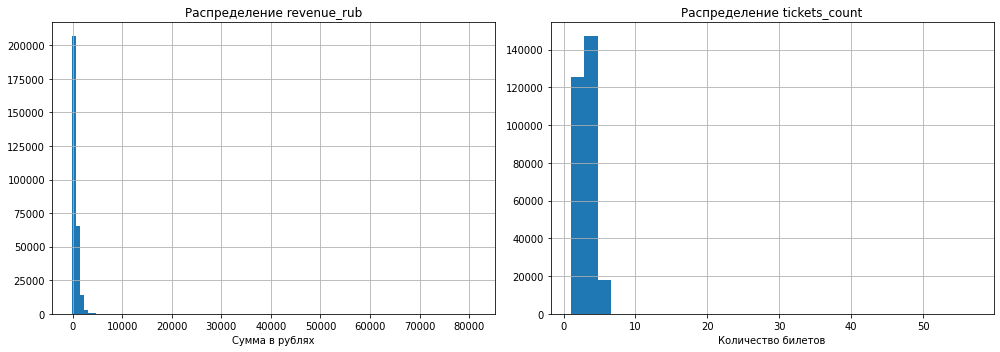

In [20]:
# Гистограммы для выявления выбросов
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['revenue_rub'].hist(bins=100, ax=axes[0])
axes[0].set_title('Распределение revenue_rub')
axes[0].set_xlabel('Сумма в рублях')

df['tickets_count'].hist(bins=30, ax=axes[1])
axes[1].set_title('Распределение tickets_count')
axes[1].set_xlabel('Количество билетов')

plt.tight_layout()
plt.show()

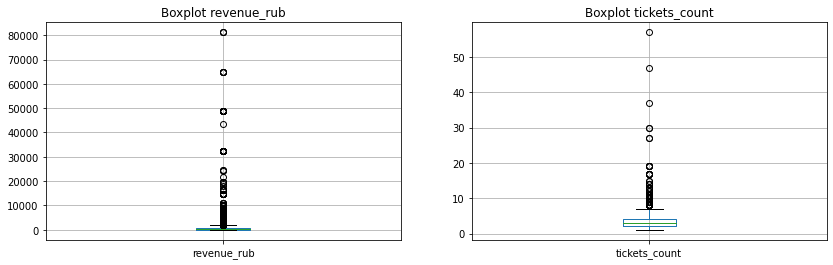

In [21]:
# Диаграммы размаха для оценки выбросов
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.boxplot(column='revenue_rub', ax=axes[0])
axes[0].set_title('Boxplot revenue_rub')
df.boxplot(column='tickets_count', ax=axes[1])
axes[1].set_title('Boxplot tickets_count')
plt.show()

In [22]:
# Найдём 99-й перцентиль для revenue_rub
percentile_99 = df['revenue_rub'].quantile(0.99)
print(f"99-й перцентиль revenue_rub: {percentile_99:.2f} руб.")

# Сколько записей превышает этот порог
n_outliers = (df['revenue_rub'] > percentile_99).sum()
print(f"Записей выше 99-го перцентиля: {n_outliers} ({n_outliers/len(df)*100:.2f}%)")

99-й перцентиль revenue_rub: 2628.42 руб.
Записей выше 99-го перцентиля: 2825 (0.97%)


In [23]:
# Фильтрация выбросов: оставляем заказы с revenue_rub не выше 99-го перцентиля
# Переменные percentile_99 и n_outliers взяты из ячейки 8
removed_before = len(df)
if n_outliers > 0:
    df = df[df['revenue_rub'] <= percentile_99].copy()
    removed = removed_before - len(df)
    print(f"Отфильтровано записей: {removed} ({removed/removed_before*100:.2f}% от данных до фильтрации)")
else:
    removed = 0
    print("Выбросов выше 99-го перцентиля не обнаружено, фильтрация не потребовалась.")

Отфильтровано записей: 2825 (0.97% от данных до фильтрации)


In [24]:
# Проверка размера данных и описательной статистики после фильтрации
print(f"Размер датафрейма после фильтрации: {df.shape}")
print("Описательная статистика revenue_rub после фильтрации:")
display(df['revenue_rub'].describe())
print("\nОписательная статистика tickets_count:")
display(df['tickets_count'].describe())

Размер датафрейма после фильтрации: (287786, 20)
Описательная статистика revenue_rub после фильтрации:


count    287786.000000
mean        518.029224
std         511.963780
min         -90.760000
25%         111.850000
50%         343.850000
75%         788.660000
max        2628.421739
Name: revenue_rub, dtype: float64


Описательная статистика tickets_count:


count    287786.000000
mean          2.740495
std           1.163073
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

In [25]:
# Оценка экономии памяти от преобразования категорий
cat_cols = ['device_type_canonical', 'currency_code', 'service_name', 
            'event_type_main', 'region_name', 'city_name']

# Текущий объём этих столбцов как category
mem_category = df[cat_cols].memory_usage(deep=True).sum() / 1024**2

# Объём тех же данных, если бы они оставались object (восстановим временно)
df_temp = df[cat_cols].astype('object')
mem_object = df_temp.memory_usage(deep=True).sum() / 1024**2

print(f"Память на категориальные столбцы как object: {mem_object:.2f} МБ")
print(f"Память на категориальные столбцы как category: {mem_category:.2f} МБ")
print(f"Экономия: {mem_object - mem_category:.2f} МБ (в {mem_object/mem_category:.1f} раза)")

Память на категориальные столбцы как object: 177.81 МБ
Память на категориальные столбцы как category: 4.19 МБ
Экономия: 173.63 МБ (в 42.5 раза)


In [26]:
# Анализ отрицательных значений выручки в рублях (возвратные операции)
neg_mask = df['revenue_rub'] < 0
neg_count = neg_mask.sum()
neg_percent = neg_count / len(df) * 100

print(f"Количество заказов с отрицательной выручкой: {neg_count} ({neg_percent:.2f}%)")
print("Распределение по валютам среди отрицательных значений:")
print(df.loc[neg_mask, 'currency_code'].value_counts())

print("\nОписательная статистика отрицательных значений:")
display(df.loc[neg_mask, 'revenue_rub'].describe())

# минимальное положительное значение
print(f"\nМинимальное положительное значение: {df.loc[~neg_mask, 'revenue_rub'].min():.2f}")

Количество заказов с отрицательной выручкой: 381 (0.13%)
Распределение по валютам среди отрицательных значений:
rub    381
kzt      0
Name: currency_code, dtype: int64

Описательная статистика отрицательных значений:


count    381.000000
mean      -2.492362
std        5.065072
min      -90.760000
25%       -3.450000
50%       -1.580000
75%       -0.650000
max       -0.010000
Name: revenue_rub, dtype: float64


Минимальное положительное значение: 0.00


**Вывод по задаче 2.2 (предобработка данных)**

- Пропуски присутствуют только в столбце `days_since_prev` (7.55% строк) — это первые заказы пользователей.
- Категориальные столбцы (`device_type_canonical`, `currency_code`, `service_name`, `event_type_main`, `region_name`, `city_name`) преобразованы в тип `category`. Это позволило сократить занимаемую ими память с 177.81 МБ (как `object`) до 4.19 МБ — экономия в 42.5 раза.
- Все категориальные значения корректны: аномалий, опечаток или неинформативных обозначений не обнаружено. В данных представлено 7 типов мероприятий (фильмы исключены ещё на этапе SQL-запроса), 2 типа устройств, 2 валюты, 36 билетных операторов, 81 регион и 352 города.
- В столбце `revenue_rub` выявлены два вида нестандартных значений:
  - **Отрицательные значения**: 381 заказ (0.13% от выборки). Все они проведены в рублях. Минимальное значение –90.76 руб., медиана –1.58 руб., среднее –2.49 руб. Предположительно это возвраты. Небольшая величина отрицательных сумм объясняется частичными возвратами, удержанием сервисных сборов или техническими корректировками.
  - **Выбросы по верхней границе**: обнаружены экстремально высокие суммы (до 81 174.54 руб. при среднем 555.13 руб.). Такие значения, вероятно, соответствуют массовым закупкам (корпоративные клиенты, перекупщики), а не техническим сбоям. Чтобы они не искажали анализ, ориентированный на обычного пользователя, была применена фильтрация по 99-му перцентилю (порог — 2 628.42 руб.). Удалено 2 825 записей (0.97% от 290 611).
- В столбце `tickets_count` экстремальных выбросов, требующих удаления, не зафиксировано.
- Итоговый размер датафрейма после всех шагов предобработки: **287 786 записей**. Данные подготовлены для построения профиля пользователя.

<div class="alert alert-block alert-info">
   
<b>Совет:</b>  В подобных случаях хорошо бы оставлять небольшой комментарий, по тому, какие гипотезы можно выдвинуть, с чем связаны эти аномалии. Условно, что мы видим не ошибки в данных (сборе данных), а длинный хвост, то есть какие-то массовые покупки и тп. Они нам не нужны в контексте задачи.
</div>




<div class="alert alert-block alert-danger">
    
<b>Ошибка:</b>  А что скажешь про отрицательные значения? Это важное наблюдение
</div>


<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> Был добавлен в отдельную ячейку код по отрицательным значениям (перед выводом по задаче 2.2. Также в выводе указал про отрицательные значеня и про выбросы по верхней границе.
</div>

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [27]:
# Сортировка данных по пользователю и времени заказа перед агрегацией
df = df.sort_values(['user_id', 'order_ts']).reset_index(drop=True)

In [28]:
# Построение профиля: агрегируем по user_id
user_profile = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
).reset_index()

In [29]:
# Функция для расчёта среднего интервала между заказами (в днях)
def mean_interval(dates):
    if len(dates) < 2:
        return None
    diffs = dates.diff().dropna()
    return diffs.mean()

# Рассчитаем среднее время между заказами для каждого пользователя
intervals = df.groupby('user_id')['order_dt'].apply(mean_interval).reset_index()
intervals.columns = ['user_id', 'mean_days_between']

# Присоединим к профилю
user_profile = user_profile.merge(intervals, on='user_id', how='left')

In [30]:
# Бинарные признаки
user_profile['is_two'] = user_profile['total_orders'] >= 2
user_profile['is_five'] = user_profile['total_orders'] >= 5

In [31]:
# Первичный осмотр профиля
print("Размер профиля:", user_profile.shape)
display(user_profile.head())
print("\nТипы данных:")
print(user_profile.dtypes)
print("\nПропуски:")
print(user_profile.isnull().sum())

Размер профиля: (21854, 13)


,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,mean_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaT,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75 days,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51 days,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaT,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16 days,True,False



Типы данных:
user_id                       object
first_order_dt        datetime64[ns]
last_order_dt         datetime64[ns]
first_device                  object
first_region                  object
first_service                 object
first_event_type              object
total_orders                   int64
avg_revenue_rub              float64
avg_tickets_count            float64
mean_days_between    timedelta64[ns]
is_two                          bool
is_five                         bool
dtype: object

Пропуски:
user_id                 0
first_order_dt          0
last_order_dt           0
first_device            0
first_region            0
first_service           0
first_event_type        0
total_orders            0
avg_revenue_rub         0
avg_tickets_count       0
mean_days_between    8368
is_two                  0
is_five                 0
dtype: int64


- Для каждого из пользователей построен профиль с 12 признаками: даты первого и последнего заказа, характеристики первой покупки (устройство, регион, билетный партнёр, тип мероприятия), количество заказов, средняя выручка, среднее число билетов и средний интервал между заказами.
- В профиле отсутствуют пропуски во всех столбцах, кроме `mean_days_between` (8 368 пропусков). Это ожидаемо: для пользователей, совершивших только один заказ, невозможно рассчитать интервал между покупками — для них значение остаётся `NaN`.
- Бинарные признаки `is_two` и `is_five` успешно добавлены и содержат корректные логические значения.
- Типы данных адекватны: даты — `datetime64`, суммы и счётчики — числа, категориальные — `object` (при необходимости можно также преобразовать в `category` для экономии памяти).


<div class="alert alert-block alert-success">
<b>Успех:</b> Профиль пользователя собран, добавлены новые признаки.

</div>

<div class="alert alert-block alert-info">
<b>Совет:</b>   Могу показать и такой вариант формирования профиля здесь:
    
    profiles = (df
            # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
            .sort_values(by='order_ts')
            # Затем группируем по номеру пользователя и агрегируем данные:
            .groupby('user_id')
            .agg(
                # Находим первую и последнюю даты заказа:
                first_order_dt=('order_dt','min'),
                last_order_dt=('order_dt','max'),
                # Находим устройства, регион и название билетного партнера первого заказа:
                first_device=('device_type_canonical','first'),
                first_region_name=('region_name','first'),
                first_service_name=('service_name','first'),
                # Жанр первого посещённого мероприятия (event_type_main):
                first_event_type=('event_type_main','first'),
                # Подсчитваем количество заказов:
                total_orders=('order_id','nunique'),
                # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
                avg_revenue_rub=('revenue_rub','mean'),
                avg_tickets_count=('tickets_count','mean'),
                # Считаем среднее количество дней между покупками:
                avg_days_since_prev=('days_since_prev','mean')
            )
            # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
            .assign(
                is_two = lambda x: x['total_orders'] >= 2,
                is_five = lambda x: x['total_orders'] >= 5
            )
            # Можно альтернативным образом подсчитать среднее количество дней между заказами (если не будет в SQL):
            .assign(
                avg_days = lambda x: (x['last_order_dt'] - x['first_order_dt']).dt.days / (x['total_orders'] - 1)
            )
            .reset_index()
)

Почитать про assign более подробно можно [здесь](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html)
</div>


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [32]:
# Общее число пользователей
total_users = len(user_profile)
print(f"Общее число пользователей: {total_users}")

Общее число пользователей: 21854


In [33]:
# Средняя выручка с одного заказа (по всем заказам всех пользователей)
avg_revenue_per_order = df['revenue_rub'].mean()
print(f"Средняя выручка с одного заказа: {avg_revenue_per_order:.2f} руб.")

Средняя выручка с одного заказа: 518.03 руб.


In [34]:
# Доли пользователей по повторным заказам
share_two = user_profile['is_two'].mean() * 100
share_five = user_profile['is_five'].mean() * 100
print(f"Доля пользователей с 2+ заказами: {share_two:.2f}%")
print(f"Доля пользователей с 5+ заказами: {share_five:.2f}%")

Доля пользователей с 2+ заказами: 61.71%
Доля пользователей с 5+ заказами: 29.01%


In [35]:
# Статистики по общему числу заказов, среднему числу билетов и среднему интервалу
print("Статистика по total_orders:")
display(user_profile['total_orders'].describe())

print("\nСтатистика по avg_tickets_count:")
display(user_profile['avg_tickets_count'].describe())

print("\nСтатистика по mean_days_between:")
display(user_profile['mean_days_between'].describe())

Статистика по total_orders:


count    21854.000000
mean        13.168573
std        121.674800
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10181.000000
Name: total_orders, dtype: float64


Статистика по avg_tickets_count:


count    21854.000000
mean         2.743129
std          0.913080
min          1.000000
25%          2.000000
50%          2.750000
75%          3.076923
max         11.000000
Name: avg_tickets_count, dtype: float64


Статистика по mean_days_between:


count                         13486
mean     15 days 21:03:42.636981359
std      22 days 06:31:34.713627042
min                 0 days 00:00:00
25%                 1 days 00:00:00
50%       8 days 01:42:51.428571428
75%                20 days 12:00:00
max               148 days 00:00:00
Name: mean_days_between, dtype: object

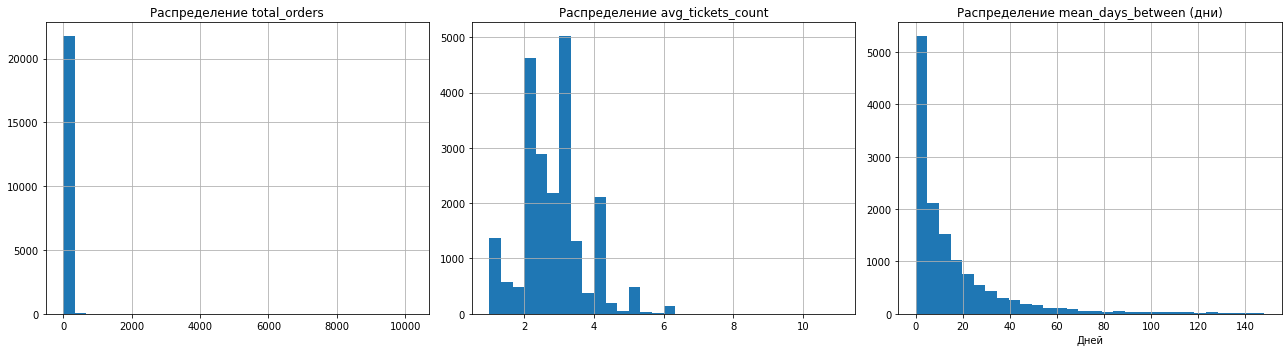

In [36]:
# Гистограммы распределений
import matplotlib.pyplot as plt

# Преобразуем timedelta в количество дней
user_profile['mean_days_between_days'] = user_profile['mean_days_between'].dt.days

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
user_profile['total_orders'].hist(bins=30, ax=axes[0])
axes[0].set_title('Распределение total_orders')

user_profile['avg_tickets_count'].hist(bins=30, ax=axes[1])
axes[1].set_title('Распределение avg_tickets_count')

user_profile['mean_days_between_days'].hist(bins=30, ax=axes[2])
axes[2].set_title('Распределение mean_days_between (дни)')
axes[2].set_xlabel('Дней')

plt.tight_layout()
plt.show()

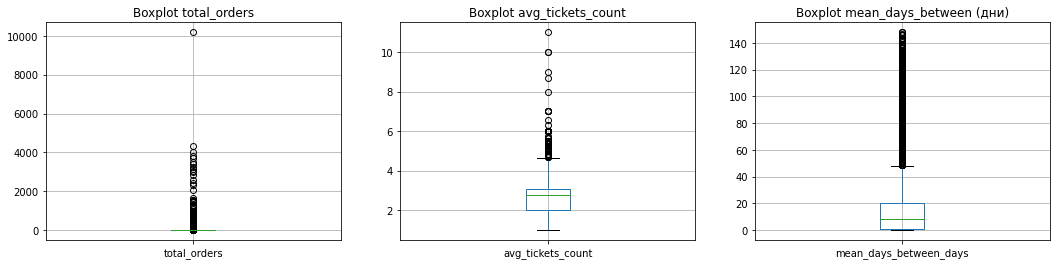

In [37]:
# Boxplot для выявления выбросов
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
user_profile.boxplot(column='total_orders', ax=axes[0])
axes[0].set_title('Boxplot total_orders')
user_profile.boxplot(column='avg_tickets_count', ax=axes[1])
axes[1].set_title('Boxplot avg_tickets_count')

# Для среднего интервала используем уже созданный числовой столбец
user_profile.boxplot(column='mean_days_between_days', ax=axes[2])
axes[2].set_title('Boxplot mean_days_between (дни)')
plt.show()

In [38]:
# Перцентили для оценки порогов аномалий
print("95-й и 99-й перцентили total_orders:")
print(user_profile['total_orders'].quantile([0.95, 0.99]))

print("\n95-й и 99-й перцентили avg_tickets_count:")
print(user_profile['avg_tickets_count'].quantile([0.95, 0.99]))

95-й и 99-й перцентили total_orders:
0.95     31.35
0.99    152.00
Name: total_orders, dtype: float64

95-й и 99-й перцентили avg_tickets_count:
0.95    4.0
0.99    5.0
Name: avg_tickets_count, dtype: float64


Данные по профилю показывают сильные выбросы в total_orders (максимум 10181 заказ), что нетипично для обычных пользователей. Медиана равна 2, а 99-й перцентиль — 152. Явно есть пользователи с аномально высокой активностью. Возможно это боты, оптовые закупки или технические сбои. Чтобы не искажать общий анализ лояльности, отфильтрованы пользователи по 99-му перцентилю total_orders (152 заказа и выше). Это удалит около 1% самых активных пользователей, но сохранит основную массу.

<div class="alert alert-block alert-success">
    
<b>Успех:</b> Классно, что не просто фиксируешь аномалии, а пытаешься найти им объяснение. 
</div>



In [39]:
# Фильтрация пользователей с аномально высоким числом заказов
# Порог — 99-й перцентиль (152), всё что >= 152 удаляем
threshold_orders = user_profile['total_orders'].quantile(0.99)
print(f"Порог фильтрации (99-й перцентиль total_orders): {threshold_orders} заказов")

n_outliers_users = (user_profile['total_orders'] >= threshold_orders).sum()
print(f"Пользователей для удаления (>= {threshold_orders} заказов): {n_outliers_users}")

user_profile_clean = user_profile[user_profile['total_orders'] < threshold_orders].copy()
removed_users = len(user_profile) - len(user_profile_clean)
print(f"Удалено пользователей: {removed_users} ({removed_users/len(user_profile)*100:.2f}%)")

Порог фильтрации (99-й перцентиль total_orders): 152.0 заказов
Пользователей для удаления (>= 152.0 заказов): 220
Удалено пользователей: 220 (1.01%)


In [40]:
# Обновлённые метрики по очищенному профилю
total_users_clean = len(user_profile_clean)
share_two_clean = user_profile_clean['is_two'].mean() * 100
share_five_clean = user_profile_clean['is_five'].mean() * 100

print(f"Число пользователей после фильтрации: {total_users_clean}")
print(f"Доля с 2+ заказами: {share_two_clean:.2f}%")
print(f"Доля с 5+ заказами: {share_five_clean:.2f}%")

print("\nСтатистика total_orders после фильтрации:")
display(user_profile_clean['total_orders'].describe())

Число пользователей после фильтрации: 21634
Доля с 2+ заказами: 61.32%
Доля с 5+ заказами: 28.28%

Статистика total_orders после фильтрации:


count    21634.000000
mean         6.474392
std         14.188048
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        151.000000
Name: total_orders, dtype: float64

- В выборке до фильтрации насчитывалось 21 854 пользователя, а после - 21 634. Средняя выручка с одного заказа составила 518.03 руб.
- Доля пользователей с повторными заказами: 61.71% (2 и более), 29.01% (5 и более) — это говорит о достаточно высоком уровне возврата.
- Распределение общего числа заказов (`total_orders`) имело сильные выбросы: максимум 10 181 заказ при медиане 2. Такие значения могли бы исказить анализ. Принято решение отфильтровать пользователей с числом заказов >= 99-го перцентиля (152 заказа). Удалено 220 пользователей (1.01% выборки).
- После фильтрации максимальное число заказов снизилось до 151, среднее — до 6.5. Доли `is_two` и `is_five` изменились незначительно (61.32% и 28.28% соответственно), значит, структура выборки по лояльности сохранилась.
- В среднем количестве билетов (`avg_tickets_count`) и среднем интервале между заказами (`mean_days_between`) аномалий, требующих дополнительной очистки, не обнаружено.
- Таким образом, данные достаточно объёмны и после очистки готовы к исследованию факторов, влияющих на возврат пользователей.

<div class="alert alert-block alert-success">
    
<b>Успех:</b> Молодец, что не просто фиксируешь аномалии, но и анализируешь как их удаление, влияет на данные
</div>




---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [41]:
# Функция для расчёта количества и доли пользователей по признаку
def segment_distribution(column, name):
    dist = user_profile_clean[column].value_counts().reset_index()
    dist.columns = [name, 'user_count']
    dist['share'] = (dist['user_count'] / len(user_profile_clean)) * 100
    return dist

In [42]:
# Распределение по типу первого мероприятия
dist_event = segment_distribution('first_event_type', 'event_type')
print("Распределение по типу первого мероприятия:")
display(dist_event)

Распределение по типу первого мероприятия:


,event_type,user_count,share
0,концерты,9558,44.180457
1,другое,5426,25.080891
2,театр,4238,19.589535
3,стендап,1109,5.126190
4,спорт,794,3.670149
5,выставки,414,1.913654
6,ёлки,95,0.439124


In [43]:
# Распределение по типу устройства
dist_device = segment_distribution('first_device', 'device_type')
print("Распределение по типу устройства:")
display(dist_device)

Распределение по типу устройства:


,device_type,user_count,share
0,mobile,17922,82.841823
1,desktop,3712,17.158177


In [44]:
# Распределение по региону (выведем топ-10)
dist_region = segment_distribution('first_region', 'region')
print("Топ-10 регионов по числу пользователей:")
display(dist_region.head(10))

Топ-10 регионов по числу пользователей:


,region,user_count,share
0,Каменевский регион,7084,32.744754
1,Североярская область,3765,17.403162
2,Широковская область,1224,5.657761
3,Озернинский край,675,3.120089
4,Малиновоярский округ,525,2.426736
5,Шанырский регион,500,2.311177
6,Травяная область,488,2.255709
7,Светополянский округ,457,2.112416
8,Речиновская область,440,2.033836
9,Яблоневская область,411,1.899787


In [45]:
# Распределение по билетному оператору (топ-10)
dist_service = segment_distribution('first_service', 'service')
print("Топ-10 билетных операторов по числу пользователей:")
display(dist_service.head(10))

Топ-10 билетных операторов по числу пользователей:


,service,user_count,share
0,Билеты без проблем,5184,23.962282
1,Мой билет,2969,13.723768
2,Лови билет!,2809,12.984192
3,Билеты в руки,2558,11.823981
4,Облачко,2177,10.062864
5,Весь в билетах,1285,5.939725
6,Лучшие билеты,1184,5.472867
7,Прачечная,582,2.690210
8,Край билетов,454,2.098549
9,Дом культуры,356,1.645558


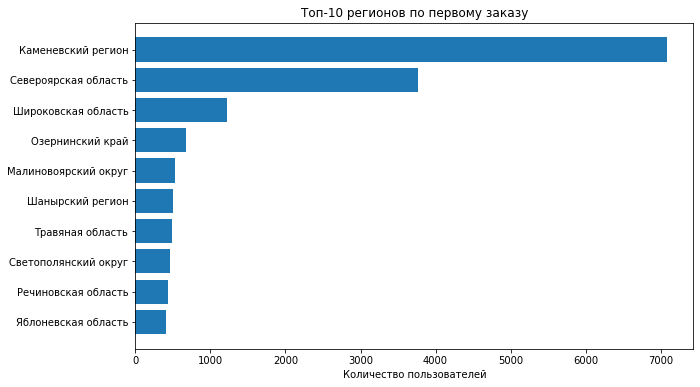

In [46]:
# Визуализация топ-10 регионов для наглядности
import matplotlib.pyplot as plt

top10_region = dist_region.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10_region['region'], top10_region['user_count'])
plt.xlabel('Количество пользователей')
plt.title('Топ-10 регионов по первому заказу')
plt.gca().invert_yaxis()
plt.show()

- Пользователи распределены по сегментам неравномерно. Выделяются главные «точки входа»:
- **Тип устройства**: подавляющее большинство первых заказов сделано с мобильных устройств (82.84%), на десктопы приходится 17.16%.
- **Тип первого мероприятия**: почти половина пользователей (44.18%) начинают с концертов. Значительные доли также у категорий «другое» (25.08%) и «театр» (19.59%). Остальные типы (стендап, спорт, выставки, ёлки) занимают небольшие доли — от 0.44% до 5.13%.
- **Регион**: на топ-10 регионов приходится около 72% всех пользователей, а лидер — Каменевский регион — в одиночку охватывает 32.74%. Это говорит о высокой географической концентрации.
- **Билетный оператор**: первая десятка операторов обслуживает около 96% пользователей, причём только три крупнейших («Билеты без проблем», «Мой билет», «Лови билет!») покрывают примерно 50% базы. Остальные 26 операторов имеют крайне маленькие сегменты.

Таким образом, явные «точки входа» — это мобильные устройства, концерты, театр, Каменевский регион и ведущие билетные операторы. Эти сегменты следует изучить в первую очередь на предмет удержания, но и небольшие сегменты могут обладать высокой лояльностью.


<div class="alert alert-block alert-success">
<b>Успех:</b> Задание выполнено корректно и лаконично через функцию, с наблюдениями согласен
    


---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [47]:
# Функция для вычисления доли пользователей с 2+ заказами в каждом сегменте
def return_rate_by_segment(df, group_col, min_size=30):
    seg = df.groupby(group_col).agg(
        total=('user_id', 'count'),
        returned=('is_two', 'sum')
    ).reset_index()
    seg['return_rate'] = (seg['returned'] / seg['total']) * 100
    seg = seg.sort_values('total', ascending=False)
    seg['size_flag'] = seg['total'].apply(lambda x: 'small' if x < min_size else 'ok')
    return seg

In [48]:
# Доля возврата по типу первого мероприятия
return_event = return_rate_by_segment(user_profile_clean, 'first_event_type')
print("Доля возврата по типу первого мероприятия:")
display(return_event)

Доля возврата по типу первого мероприятия:


,first_event_type,total,returned,return_rate,size_flag
2,концерты,9558,5909,61.822557,ok
1,другое,5426,3235,59.620346,ok
5,театр,4238,2686,63.378952,ok
4,стендап,1109,675,60.865645,ok
3,спорт,794,443,55.793451,ok
0,выставки,414,265,64.009662,ok
6,ёлки,95,53,55.789474,ok


In [49]:
# Доля возврата по типу устройства
return_device = return_rate_by_segment(user_profile_clean, 'first_device')
print("Доля возврата по типу устройства:")
display(return_device)

Доля возврата по типу устройства:


,first_device,total,returned,return_rate,size_flag
1,mobile,17922,10898,60.807946,ok
0,desktop,3712,2368,63.793103,ok


In [50]:
# Доля возврата по регионам (топ-10 среди крупных сегментов размером >= 30)
return_region = return_rate_by_segment(user_profile_clean, 'first_region')
print("Топ-10 регионов по доле возврата (среди крупных):")
display(return_region[return_region['size_flag'] == 'ok'].head(10))

Топ-10 регионов по доле возврата (среди крупных):


,first_region,total,returned,return_rate,size_flag
23,Каменевский регион,7084,4420,62.394128,ok
60,Североярская область,3765,2402,63.798141,ok
77,Широковская область,1224,790,64.542484,ok
45,Озернинский край,675,373,55.259259,ok
41,Малиновоярский округ,525,294,56.000000,ok
76,Шанырский регион,500,336,67.200000,ok
74,Травяная область,488,300,61.475410,ok
57,Светополянский округ,457,300,65.645514,ok
52,Речиновская область,440,279,63.409091,ok
78,Яблоневская область,411,244,59.367397,ok


In [51]:
# Доля возврата по билетным операторам (топ-10 среди крупных)
return_service = return_rate_by_segment(user_profile_clean, 'first_service')
print("Топ-10 билетных операторов по доле возврата (среди крупных):")
display(return_service[return_service['size_flag'] == 'ok'].head(10))

Топ-10 билетных операторов по доле возврата (среди крупных):


,first_service,total,returned,return_rate,size_flag
3,Билеты без проблем,5184,3131,60.397377,ok
22,Мой билет,2969,1807,60.862243,ok
19,Лови билет!,2809,1711,60.911356,ok
4,Билеты в руки,2558,1604,62.705238,ok
23,Облачко,2177,1334,61.276987,ok
7,Весь в билетах,1285,808,62.879377,ok
20,Лучшие билеты,1184,725,61.233108,ok
24,Прачечная,582,364,62.542955,ok
17,Край билетов,454,296,65.198238,ok
12,Дом культуры,356,230,64.606742,ok


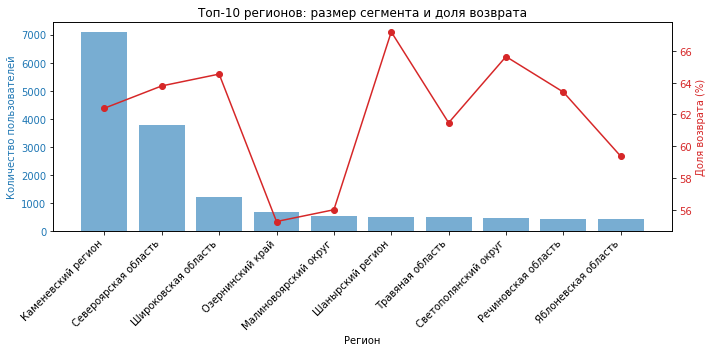

In [52]:
# Визуализация: топ-10 регионов по размеру и доля возврата
import matplotlib.pyplot as plt

top10_region = return_region.head(10)
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.bar(top10_region['first_region'], top10_region['total'], color=color, alpha=0.6, label='Все пользователи')
ax1.set_xlabel('Регион')
ax1.set_ylabel('Количество пользователей', color=color)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(top10_region['first_region'], top10_region['return_rate'], color=color, marker='o', label='Доля возврата (%)')
ax2.set_ylabel('Доля возврата (%)', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Топ-10 регионов: размер сегмента и доля возврата')
fig.tight_layout()
plt.show()

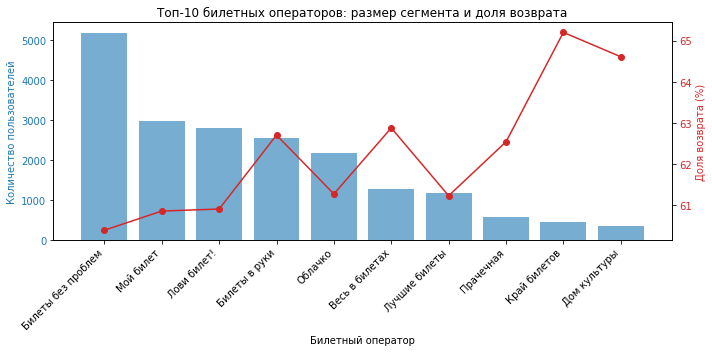

In [53]:
# Визуализация: топ-10 билетных операторов по размеру и доля возврата
top10_service = return_service.head(10)
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.bar(top10_service['first_service'], top10_service['total'], color=color, alpha=0.6, label='Все пользователи')
ax1.set_xlabel('Билетный оператор')
ax1.set_ylabel('Количество пользователей', color=color)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(top10_service['first_service'], top10_service['return_rate'], color=color, marker='o', label='Доля возврата (%)')
ax2.set_ylabel('Доля возврата (%)', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Топ-10 билетных операторов: размер сегмента и доля возврата')
fig.tight_layout()
plt.show()

**Краткий вывод**

- **Средняя доля возврата по всей выборке** составляет 61.32% (пользователи с 2+ заказами). Эта величина может считаться бенчмарком для дальнейшего исследования.
- **По типу первого мероприятия:**
  - Самый высокий возврат дают «выставки» (64.01%) и «театр» (63.38%).
  - Лидер по объёму — «концерты» (44.18% всех пользователей) — также показывает уровень выше среднего (61.82%).
  - Наименьшая доля возврата у категорий «спорт» (55.79%) и «ёлки» (55.79%), при этом это малочисленные сегменты (3.7% и 0.44% базы соответственно). Низкая лояльность здесь может быть статистически менее надёжной, но сигнал заметен.
- **По типу устройства:**
  - Пользователи десктопов возвращаются чуть чаще (63.79%), чем пользователи мобильных (60.81%), хотя различие невелико.
  - Мобильные устройства остаются главной «точкой входа» (82.84% пользователей).
- **По регионам:**
  - Среди крупных регионов (более 400 пользователей) повышенной долей возврата выделяются:
    - Шанырский регион (67.20% при 500 пользователях),
    - Светополянский округ (65.65% при 457 пользователях),
    - Широковская область (64.54% при 1224 пользователях).
  - Крупнейший регион — Каменевский — показывает 62.39%, что выше среднего и подтверждает его статус успешной «точки входа».
  - Заметно отстают Озернинский край (55.26%) и Малиновоярский округ (56.00%) — здесь возврат существенно ниже среднего, что может говорить о необходимости дополнительных маркетинговых усилий.
- **По билетным операторам:**
  - Среди операторов с достаточным размером (от 350 пользователей) лидируют:
    - Край билетов (65.20% возврата при 454 пользователях),
    - Дом культуры (64.61% при 356 пользователях).
  - Крупнейшие операторы («Билеты без проблем», «Мой билет», «Лови билет!») держатся около среднего (60–61%), что вполне приемлемо, учитывая их массовость.
  - Явных провалов среди крупных операторов нет.
- **Интерпретация размера сегментов:** Все сегменты, участвующие в сравнении, имеют не менее 350 пользователей, поэтому оценки долей можно считать достаточно устойчивыми. Сегменты с десятками пользователей («ёлки», мелкие операторы) не рассматривались в выводах как статистически значимые.
- **Ответы на вопросы:**
  - Чаще возвращаются пользователи, чей первый заказ был на выставку или в театр, сделан с десктопа, в регионах-лидерах по возврату (Шанырский регион, Светополянский округ, Широковская область) и через операторов «Край билетов», «Дом культуры».
  - Да, наблюдаются успешные «точки входа», где доля повторных заказов заметно выше средней (например, Шанырский регион, Светополянский округ, выставки, десктоп). Эти сегменты можно рассматривать как примеры хорошего удержания.


<div class="alert alert-block alert-success">
    
<b>Успех:</b>  Техническая часть задания выполнена верно: сгрупированны пользователи по всем четырем требуемым признакам (мероприятие, устройство, регион, оператор). Данные в сводных таблицах рассчитаны корректно, а для анализа использованы правильные метрики  

Итоговый вывод соответствует цифрам.  Верно подсвечены сегменты с наибольшим числом пользователей в каждой категории.
</div>



---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [54]:
# Проверка гипотезы 1: сравнение доли возврата между первым заказом на спортивные мероприятия и на концерты
sport_rate = return_event[return_event['first_event_type'] == 'спорт']['return_rate'].values[0]
concert_rate = return_event[return_event['first_event_type'] == 'концерты']['return_rate'].values[0]

print(f"Доля возврата (2+ заказов) для первого заказа на спорт: {sport_rate:.2f}%")
print(f"Доля возврата для первого заказа на концерты: {concert_rate:.2f}%")
print(f"Разница (спорт - концерты): {sport_rate - concert_rate:.2f} процентных пункта")

sport_total = return_event[return_event['first_event_type'] == 'спорт']['total'].values[0]
concert_total = return_event[return_event['first_event_type'] == 'концерты']['total'].values[0]
print(f"Число пользователей в сегменте «спорт»: {sport_total}")
print(f"Число пользователей в сегменте «концерты»: {concert_total}")

Доля возврата (2+ заказов) для первого заказа на спорт: 55.79%
Доля возврата для первого заказа на концерты: 61.82%
Разница (спорт - концерты): -6.03 процентных пункта
Число пользователей в сегменте «спорт»: 794
Число пользователей в сегменте «концерты»: 9558


Коэффициент корреляции Пирсона между размером региона и долей возврата: 0.214


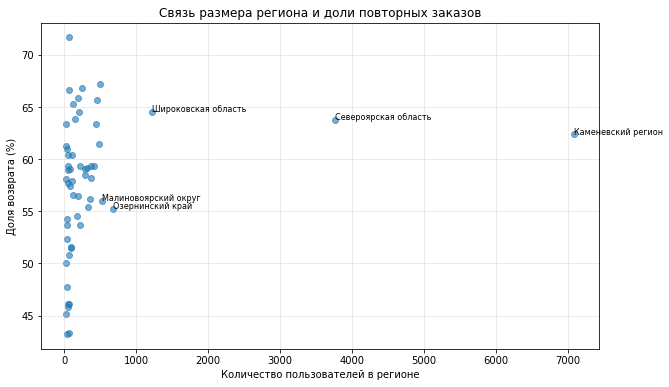

In [55]:
# Проверка гипотезы 2: связь размера региона и доли возврата
# Берём только регионы с достаточным количеством пользователей (size_flag == 'ok')
regions_ok = return_region[return_region['size_flag'] == 'ok'].copy()

corr = regions_ok['total'].corr(regions_ok['return_rate'])
print(f"Коэффициент корреляции Пирсона между размером региона и долей возврата: {corr:.3f}")

# Визуализация
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(regions_ok['total'], regions_ok['return_rate'], alpha=0.6)
plt.xlabel('Количество пользователей в регионе')
plt.ylabel('Доля возврата (%)')
plt.title('Связь размера региона и доли повторных заказов')
plt.grid(True, alpha=0.3)

# Подпишем несколько крупнейших регионов
for _, row in regions_ok.nlargest(5, 'total').iterrows():
    plt.annotate(row['first_region'], (row['total'], row['return_rate']), fontsize=8)
plt.show()

**Гипотеза 1 (спортивные мероприятия и концерты):**
- Доля возврата среди пользователей, начавших со спортивных мероприятий, составила 55.79%, а среди начавших с концертов — 61.82%.
- Гипотеза о том, что «спортивные» пользователи возвращаются чаще, **не подтвердилась** — наблюдается обратная картина. Разница (спорт минус концерты) равна -6.03 процентных пункта.
- Сегмент «спорт» относительно невелик (794 пользователя против 9 558 у концертов), поэтому оценки могут быть несколько менее устойчивыми, но направление различий явное и не в пользу гипотезы.

**Гипотеза 2 (регионы с большим числом пользователей имеют более высокую долю возврата):**
- Коэффициент корреляции Пирсона между количеством пользователей в регионе и долей повторных заказов равен 0.214 — это слабая положительная связь.
- Визуально на графике видно, что крупнейшие регионы не всегда лидируют по возврату, а некоторые средние по размеру регионы (например, Шанырский, Светополянский округ) демонстрируют долю выше средней.
- Гипотеза **скорее не находит убедительного подтверждения** — высокая посещаемость региона сама по себе не гарантирует повышенной лояльности. Значимой монотонной зависимости не обнаружено.

<div class="alert alert-block alert-success">
<b>Успех:</b> Согласен


</div>

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [56]:
# Подготовка: выделим две группы пользователей по признаку is_two
group1 = user_profile_clean[~user_profile_clean['is_two']] # один заказ
group2 = user_profile_clean[user_profile_clean['is_two']]  # 2 и более заказов

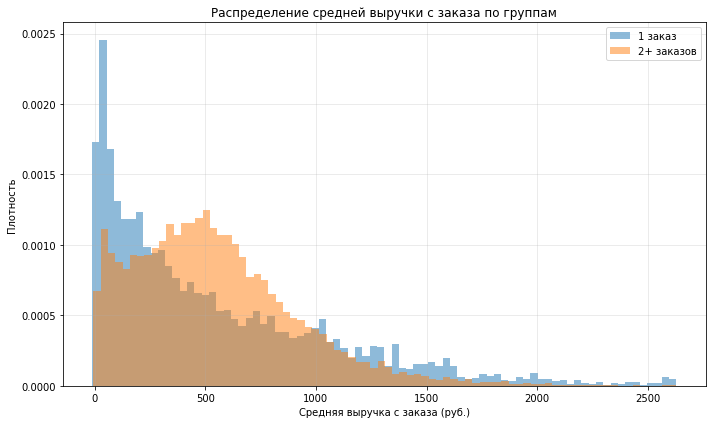

In [57]:
# Сравнительная гистограмма распределения средней выручки с заказа (avg_revenue_rub)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(group1['avg_revenue_rub'], bins=80, alpha=0.5, density=True, label='1 заказ')
plt.hist(group2['avg_revenue_rub'], bins=80, alpha=0.5, density=True, label='2+ заказов')
plt.xlabel('Средняя выручка с заказа (руб.)')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки с заказа по группам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# Описательные статистики по группам для дополнения вывода
print("Статистика avg_revenue_rub для группы с 1 заказом:")
display(group1['avg_revenue_rub'].describe())

print("\nСтатистика avg_revenue_rub для группы с 2+ заказами:")
display(group2['avg_revenue_rub'].describe())

print("\nМедиана и среднее:")
print(f"1 заказ: медиана = {group1['avg_revenue_rub'].median():.2f}, среднее = {group1['avg_revenue_rub'].mean():.2f}")
print(f"2+ заказов: медиана = {group2['avg_revenue_rub'].median():.2f}, среднее = {group2['avg_revenue_rub'].mean():.2f}")

Статистика avg_revenue_rub для группы с 1 заказом:


count    8368.000000
mean      545.295642
std       519.514097
min       -10.770000
25%       132.070000
50%       378.030000
75%       830.317500
max      2628.421739
Name: avg_revenue_rub, dtype: float64


Статистика avg_revenue_rub для группы с 2+ заказами:


count    13266.000000
mean       544.332541
std        369.409471
min         -5.385000
25%        270.647500
50%        495.683962
75%        745.222000
max       2628.421739
Name: avg_revenue_rub, dtype: float64


Медиана и среднее:
1 заказ: медиана = 378.03, среднее = 545.30
2+ заказов: медиана = 495.68, среднее = 544.33


**Краткий вывод**

- Распределения средней выручки с заказа в обеих группах имеют схожую форму: основная масса пользователей концентрируется в диапазоне до 1000–1200 руб.
- Однако заметны различия:
  - У пользователей с **одним заказом** медианная средняя выручка составляет **378.03 руб.**, распределение сильнее сконцентрировано в области низких значений (нижний квартиль 132.07 руб.).
  - У **вернувшихся пользователей (2+ заказов)** медиана заметно выше — **495.68 руб.**, распределение сдвинуто вправо: значительно больше пользователей имеют средний чек выше 400–500 руб.
- Средние значения близки (545.30 против 544.33), что объясняется наличием высоких значений в обеих группах, но медиана наглядно подтверждает сдвиг.
- Таким образом, пользователи, которые в среднем тратят больше на один заказ, имеют большую склонность возвращаться на платформу. Однако различие не кардинальное — обе группы охватывают широкий диапазон сумм.


<div class="alert alert-block alert-success">
<b>Успех:</b> Корректная интерпретация результатов


</div>



<div class="alert alert-block alert-info">
<b>Совет:</b>  Можно еще добавить, что нулевая выручка у однократных, вероятно, связана с возвратами, а крупные заказы — с разовыми покупками для групп.

</div>




---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [59]:
# Выделение двух групп пользователей
group_2_4 = user_profile_clean[(user_profile_clean['total_orders'] >= 2) & (user_profile_clean['total_orders'] <= 4)]
group_5plus = user_profile_clean[user_profile_clean['total_orders'] >= 5]

print(f"Число пользователей в группе 2–4 заказа: {len(group_2_4)}")
print(f"Число пользователей в группе 5+ заказов: {len(group_5plus)}")

Число пользователей в группе 2–4 заказа: 7147
Число пользователей в группе 5+ заказов: 6119


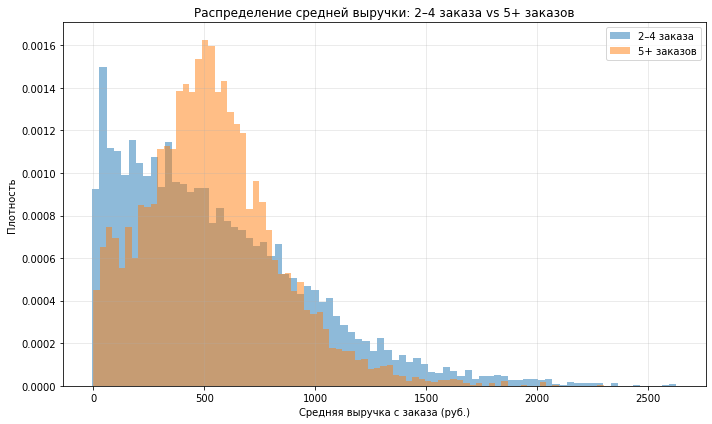

Статистика avg_revenue_rub для 2–4 заказов:


count    7147.000000
mean      551.572386
std       420.197691
min        -5.385000
25%       218.428750
50%       471.266667
75%       798.550000
max      2628.421739
Name: avg_revenue_rub, dtype: float64


Статистика avg_revenue_rub для 5+ заказов:


count    6119.000000
mean      535.876392
std       299.185155
min         0.000000
25%       330.390440
50%       512.504000
75%       700.874507
max      2299.869022
Name: avg_revenue_rub, dtype: float64


Медиана и среднее:
2–4 заказа: медиана = 471.27, среднее = 551.57
5+ заказов: медиана = 512.50, среднее = 535.88


In [60]:
# Сравнительная гистограмма и статистики средней выручки для двух групп
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(group_2_4['avg_revenue_rub'], bins=80, alpha=0.5, density=True, label='2–4 заказа')
plt.hist(group_5plus['avg_revenue_rub'], bins=80, alpha=0.5, density=True, label='5+ заказов')
plt.xlabel('Средняя выручка с заказа (руб.)')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки: 2–4 заказа vs 5+ заказов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Описательные статистики
print("Статистика avg_revenue_rub для 2–4 заказов:")
display(group_2_4['avg_revenue_rub'].describe())

print("\nСтатистика avg_revenue_rub для 5+ заказов:")
display(group_5plus['avg_revenue_rub'].describe())

print("\nМедиана и среднее:")
print(f"2–4 заказа: медиана = {group_2_4['avg_revenue_rub'].median():.2f}, среднее = {group_2_4['avg_revenue_rub'].mean():.2f}")
print(f"5+ заказов: медиана = {group_5plus['avg_revenue_rub'].median():.2f}, среднее = {group_5plus['avg_revenue_rub'].mean():.2f}")

**Краткий вывод**

- **Размер групп:** 7 147 пользователей с 2–4 заказами и 6 119 с 5+ заказами. Группы сравнимы по численности.
- **Различия в средней выручке с заказа:**
  - В группе 2–4 заказов медиана составляет 471.27 руб., а в группе 5+ заказов — 512.50 руб. Это говорит о том, что **более лояльные пользователи (5+ заказов) склонны тратить немного больше на один заказ**.
  - Средние значения близки (551.57 против 535.88), причём среднее в группе 2–4 несколько выше из-за отдельных пользователей с экстремально высоким средним чеком.
  - Стандартное отклонение в группе 2–4 заказов (420.20) заметно больше, чем в группе 5+ (299.19). Это означает, что в группе с меньшей лояльностью больше разброс: есть как очень дешёвые заказы, так и очень дорогие. У постоянных клиентов средняя выручка стабильнее и сконцентрирована в среднем диапазоне.
- **Визуально** на гистограмме оба распределения имеют схожую форму, но у группы 5+ пик немного смещён вправо, а «хвост» в области высоких значений менее выражен.
- **Вывод:** Существует небольшое, но заметное различие: пользователи, делающие 5 и более заказов, в среднем приносят чуть больше выручки за один заказ (медиана на 41.23 руб. выше). При этом основная масса в обеих группах сосредоточена в диапазоне от 200–300 до 800–1000 руб.


<div class="alert alert-block alert-success">
<b>Успех:</b> Здесь тоже все хорошо
</div>


<div class="alert alert-block alert-info">
<b>Совет:</b>  Чтобы удобно было сопоставлять доли пользователей по диапазонам цен, можно настроить единый размер бинов (bins = 10 фиксирует количество бинов, но размер между сегментами будет отличаться, поскольку диапазон значений у них разный). Для этого в bins можно передать границы для формирования бинов с шагом: bins = range(min_value, max_value+1, 50), максимальное и минимальное значения при этом определяем на всей выборке, а не отдельно для каждого сегмента.
    
---
    
Если хочется копнуть глубже 
    
- **Matplotlib: настройка параметра `bins` в гистограмме**  
  https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html

- **Seaborn: документация `histplot` с примерами**  
  https://seaborn.pydata.org/generated/seaborn.histplot.html

- **Real Python: подробный гайд по гистограммам (англ.)**  
  https://realpython.com/python-histograms/
</div>	


---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

Статистика avg_tickets_count:


count    21634.000000
mean         2.743321
std          0.917570
min          1.000000
25%          2.000000
50%          2.750000
75%          3.097339
max         11.000000
Name: avg_tickets_count, dtype: float64

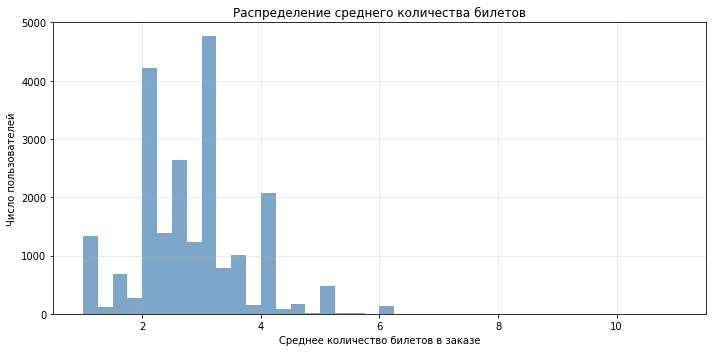

In [61]:
# Изучение распределения avg_tickets_count
import matplotlib.pyplot as plt

print("Статистика avg_tickets_count:")
display(user_profile_clean['avg_tickets_count'].describe())

plt.figure(figsize=(10, 5))
plt.hist(user_profile_clean['avg_tickets_count'], bins=40, alpha=0.7, color='steelblue')
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Число пользователей')
plt.title('Распределение среднего количества билетов')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
# Сегментация пользователей по среднему количеству билетов
bins = [1, 2, 3, 5, float('inf')]
labels = ['1 до 2', '2 до 3', '3 до 5', '5 и более']

user_profile_clean['ticket_segment'] = pd.cut(
    user_profile_clean['avg_tickets_count'], 
    bins=bins, 
    labels=labels, 
    right=False, 
    include_lowest=True
)

In [63]:
# Подсчёт числа пользователей и доли возврата в каждом сегменте
segment_stats = user_profile_clean.groupby('ticket_segment', observed=False).agg(
    total=('user_id', 'count'),
    returned=('is_two', 'sum')
).reset_index()
segment_stats['return_rate'] = (segment_stats['returned'] / segment_stats['total']) * 100

print("Сегменты по среднему количеству билетов:")
display(segment_stats[['ticket_segment', 'total', 'returned', 'return_rate']])

Сегменты по среднему количеству билетов:


,ticket_segment,total,returned,return_rate
0,1 до 2,2419,1241,51.302191
1,2 до 3,9494,6985,73.572783
2,3 до 5,9060,4916,54.260486
3,5 и более,661,124,18.759455


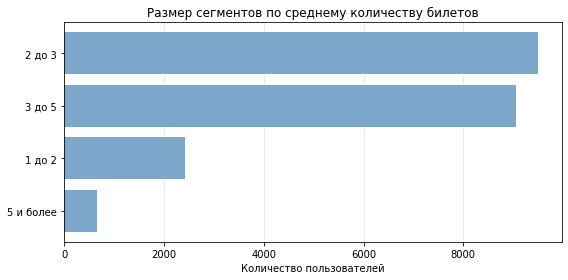

In [64]:
# Размер сегментов
seg_sorted_total = segment_stats.sort_values('total', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(seg_sorted_total['ticket_segment'], seg_sorted_total['total'], color='steelblue', alpha=0.7)
plt.xlabel('Количество пользователей')
plt.title('Размер сегментов по среднему количеству билетов')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

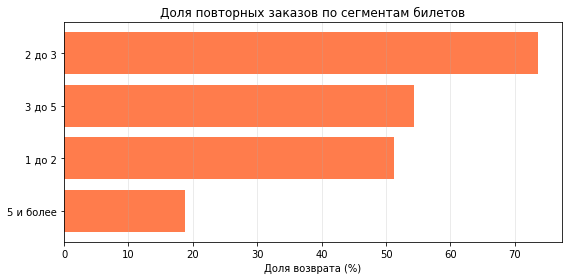

In [65]:
# Доля возврата в сегментах
seg_sorted_rate = segment_stats.sort_values('return_rate', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(seg_sorted_rate['ticket_segment'], seg_sorted_rate['return_rate'], color='orangered', alpha=0.7)
plt.xlabel('Доля возврата (%)')
plt.title('Доля повторных заказов по сегментам билетов')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Краткий вывод**

- Пользователи распределены по сегментам неравномерно: основная масса сконцентрирована в диапазонах «2 до 3» (9 494 чел., 43.9%) и «3 до 5» билетов (9 060 чел., 41.9%). Сегменты «1 до 2» (2 419 чел.) и особенно «5 и более» (661 чел.) значительно меньше.
- **Доля повторных заказов** сильно различается между сегментами:
  - ****Аномально высокая**** — в сегменте «2 до 3 билетов»: 73.6% (при средней по выборке 61.3%). Это говорит о том, что пользователи, покупающие в среднем 2–3 билета на заказ, наиболее склонны возвращаться.
  - **Заметно низкая** — в сегменте «5 и более билетов»: всего 18.8%. Однако сегмент малочисленный, и такая доля может быть как следствием особого поведения (разовые крупные покупки), так и статистической неустойчивостью.
  - Сегменты «1 до 2» (51.3%) и «3 до 5» (54.3%) находятся ниже среднего, но без резких отклонений.
- **Основное наблюдение:** существует «оптимальный» диапазон среднего числа билетов (2–3), при котором вероятность повторных покупок максимальна. Слишком маленькие (1–2) и слишком большие (5+) заказы характерны для менее лояльных пользователей.


<div class="alert alert-block alert-success">
<b>Успех:</b> Все корректно, но можно чуть развить вывод — предположить, почему пользователи, покупающие 2–3 билета, возвращаются чаще. Например, это могут быть небольшие компании или семьи, которые чаще ходят на мероприятия вместе, а значит, лояльность у них выше. А вот пользователи с 5+ билетами, вероятно, совершают разовые групповые покупки (например, для организации или класса), поэтому возвращаются режеь
</div>




---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [66]:
# Извлечение дня недели из даты первого заказа
# weekday: понедельник=0, воскресенье=6
user_profile_clean['first_order_weekday'] = user_profile_clean['first_order_dt'].dt.weekday

In [67]:
# Подсчёт числа пользователей и доли возврата по дням недели
weekday_stats = user_profile_clean.groupby('first_order_weekday').agg(
    total=('user_id', 'count'),
    returned=('is_two', 'sum')
).reset_index()
weekday_stats['return_rate'] = (weekday_stats['returned'] / weekday_stats['total']) * 100

# Переведём числовой день в название для наглядности
days_map = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
weekday_stats['weekday_name'] = weekday_stats['first_order_weekday'].map(days_map)
weekday_stats = weekday_stats.sort_values('first_order_weekday')

print("Распределение пользователей и доля возврата по дням недели:")
display(weekday_stats[['weekday_name', 'total', 'returned', 'return_rate']])

Распределение пользователей и доля возврата по дням недели:


,weekday_name,total,returned,return_rate
0,Пн,2929,1846,63.024923
1,Вт,3175,1965,61.889764
2,Ср,3057,1901,62.185149
3,Чт,3113,1850,59.428204
4,Пт,3259,1950,59.834305
5,Сб,3324,2087,62.785800
6,Вс,2777,1667,60.028808


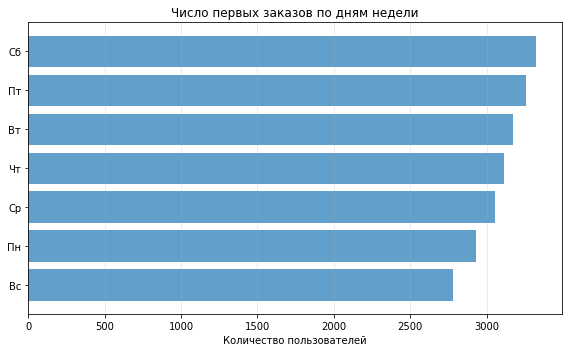

In [68]:
# Горизонтальный график: количество пользователей по дням недели
import matplotlib.pyplot as plt

# Сортируем по убыванию количества — максимум будет вверху
weekday_sorted_total = weekday_stats.sort_values('total', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(weekday_sorted_total['weekday_name'], weekday_sorted_total['total'], color='tab:blue', alpha=0.7)
plt.xlabel('Количество пользователей')
plt.title('Число первых заказов по дням недели')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

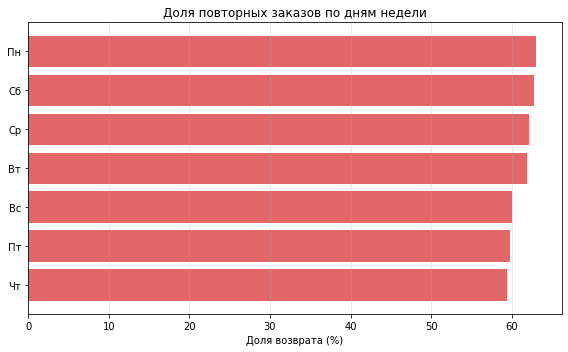

In [69]:
# Горизонтальный график: доля возврата по дням недели
weekday_sorted_rate = weekday_stats.sort_values('return_rate', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(weekday_sorted_rate['weekday_name'], weekday_sorted_rate['return_rate'], color='tab:red', alpha=0.7)
plt.xlabel('Доля возврата (%)')
plt.title('Доля повторных заказов по дням недели')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Краткий вывод**

- Количество первых заказов по дням недели распределено относительно равномерно: от 2 777 (воскресенье) до 3 324 (суббота). Явного доминирующего дня нет.
- Доля вернувшихся пользователей колеблется в узком диапазоне:
  - Максимум в понедельник — 63.02%, минимум в четверг — 59.43%.
  - Разница между наибольшим и наименьшим значением составляет всего 3.6 процентных пункта.
- График подтверждает, что кривая доли возврата практически плоская, без выраженных пиков или провалов.
- **Вывод:** день недели, в который совершён первый заказ, не оказывает значимого влияния на вероятность повторной покупки. Различия между днями минимальны и не позволяют выделить какой-либо день как более «успешный» для привлечения лояльных пользователей.




<div class="alert alert-block alert-success">
<b>Успех:</b> Верно, когда планируют досуг, но возвращаемость остаётся примерно одинаковой — это говорит о том, что день недели первой покупки не влияет на лояльность, а повторное использование сервиса определяется скорее качеством опыта и интересом к мероприятиям
</div>


---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [70]:
# Расчёт статистик среднего интервала между заказами для двух групп
# Используем группы group_2_4 и group_5plus из задачи 4.2.2 (уже должны быть созданы)
group_2_4 = user_profile_clean[(user_profile_clean['total_orders'] >= 2) & (user_profile_clean['total_orders'] <= 4)]
group_5plus = user_profile_clean[user_profile_clean['total_orders'] >= 5]

# Рассчитаем среднее и медиану интервала (в днях)
mean_interval_2_4 = group_2_4['mean_days_between'].mean()
median_interval_2_4 = group_2_4['mean_days_between'].median()
mean_interval_5plus = group_5plus['mean_days_between'].mean()
median_interval_5plus = group_5plus['mean_days_between'].median()

print("Группа 2–4 заказа:")
print(f"  Число пользователей: {len(group_2_4)}")
print(f"  Средний интервал между заказами (среднее): {mean_interval_2_4}")
print(f"  Средний интервал между заказами (медиана): {median_interval_2_4}")

print("\nГруппа 5+ заказов:")
print(f"  Число пользователей: {len(group_5plus)}")
print(f"  Средний интервал между заказами (среднее): {mean_interval_5plus}")
print(f"  Средний интервал между заказами (медиана): {median_interval_5plus}")

# Дополнительно преобразуем timedelta в дни для наглядности
mean_interval_2_4_days = group_2_4['mean_days_between_days'].mean()
median_interval_2_4_days = group_2_4['mean_days_between_days'].median()
mean_interval_5plus_days = group_5plus['mean_days_between_days'].mean()
median_interval_5plus_days = group_5plus['mean_days_between_days'].median()

print("\nВ днях:")
print(f"  2-4 заказа: среднее = {mean_interval_2_4_days:.1f} дн., медиана = {median_interval_2_4_days:.1f} дн.")
print(f"  5+ заказов: среднее = {mean_interval_5plus_days:.1f} дн., медиана = {median_interval_5plus_days:.1f} дн.")

Группа 2–4 заказа:
  Число пользователей: 7147
  Средний интервал между заказами (среднее): 21 days 09:46:22.985868196
  Средний интервал между заказами (медиана): 9 days 00:00:00

Группа 5+ заказов:
  Число пользователей: 6119
  Средний интервал между заказами (среднее): 9 days 23:20:48.919395694
  Средний интервал между заказами (медиана): 8 days 05:20:00

В днях:
  2-4 заказа: среднее = 21.3 дн., медиана = 9.0 дн.
  5+ заказов: среднее = 9.6 дн., медиана = 8.0 дн.


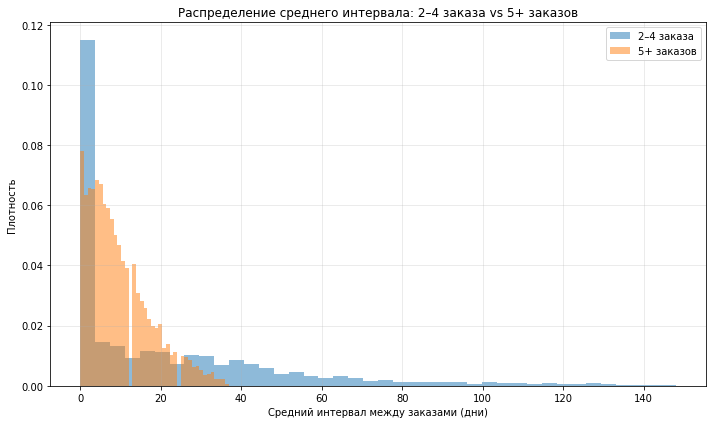

In [71]:
# Сравнительная гистограмма распределений среднего интервала (в днях)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(group_2_4['mean_days_between_days'].dropna(), bins=40, alpha=0.5, density=True, label='2–4 заказа')
plt.hist(group_5plus['mean_days_between_days'].dropna(), bins=40, alpha=0.5, density=True, label='5+ заказов')
plt.xlabel('Средний интервал между заказами (дни)')
plt.ylabel('Плотность')
plt.title('Распределение среднего интервала: 2–4 заказа vs 5+ заказов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Краткий вывод**

- **Группа 2–4 заказа:** средний интервал между заказами составляет 21.3 дня (медиана — 9.0 дней).
- **Группа 5+ заказов:** средний интервал между заказами значительно меньше — 9.6 дней (медиана — 8.0 дней).
- Различие наглядно: более лояльные пользователи (5+ заказов) совершают покупки **в среднем вдвое чаще**, чем пользователи с 2–4 заказами.
- На гистограмме видно, что распределение группы 5+ заметно сдвинуто влево: значительно больше пользователей имеют интервал до 10 дней, а длинные интервалы (свыше 40–50 дней) встречаются реже.  
Существует обратная связь между средним интервалом и количеством заказов. Чем короче интервал между покупками, тем выше вероятность, что пользователь совершит 5 и более заказов. Сокращение времени между заказами может быть как причиной, так и следствием высокой лояльности, но в любом случае это полезный сигнал для прогнозирования удержания.

<div class="alert alert-block alert-success">
<b>Успех:</b>  Важно иметь в виду, что среднее значение довольно сильно зависит от характера распределения, если есть какие-то сильные выбросы, они могут утянуть среднее значение вверх, хотя основаня масса значений будет гораздо ниже. Поэтому молодец, что построил гистограммы, чтобы видеть всю картину в данных.
</div>


---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [72]:
# Установка и импорт библиотеки phik
!pip install -q phik
import phik
from phik import resources
from phik.phik import phik_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
# Подготовка набора признаков для корреляционного анализа
# Используем профиль пользователя user_profile_clean

# Нужно убедиться, что есть столбец mean_days_between_days (переведённый в дни)
if 'mean_days_between_days' not in user_profile_clean.columns:
    # На случай, если не создан — создаём из timedelta
    user_profile_clean['mean_days_between_days'] = user_profile_clean['mean_days_between'].dt.days

# Список признаков
features = [
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'avg_revenue_rub',
    'avg_tickets_count',
    'mean_days_between_days',
    'first_order_weekday'
]

# Целевая переменная — total_orders
df_corr = user_profile_clean[features + ['total_orders']].copy()

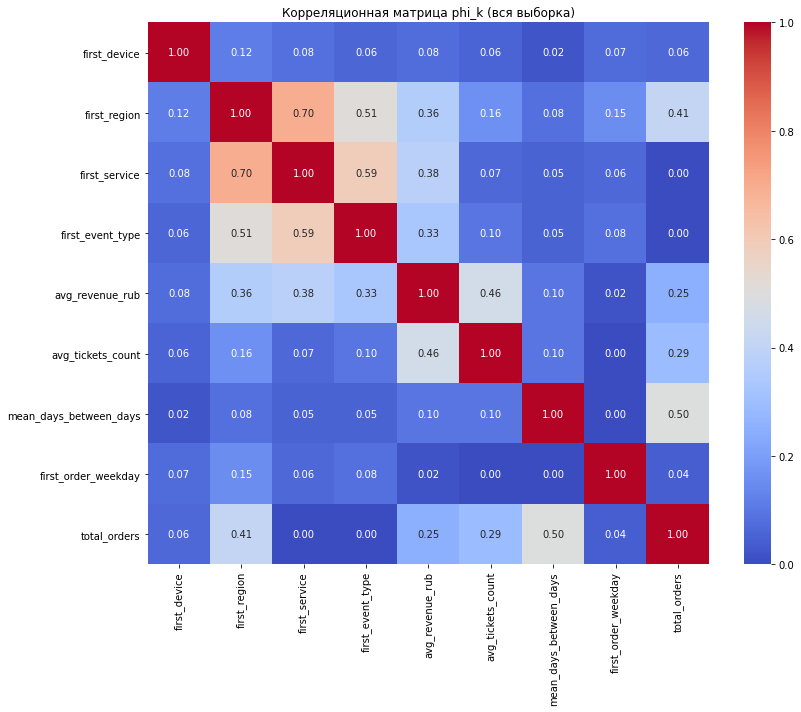

In [74]:
# Расчёт phi_k на всей выборке (без сегментации)
interval_cols = ['avg_revenue_rub', 'avg_tickets_count', 'mean_days_between_days', 'first_order_weekday']

phi_matrix_all = phik_matrix(df_corr, interval_cols=interval_cols)

# Тепловая карта
plt.figure(figsize=(12, 10))
sns.heatmap(phi_matrix_all, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.2f')
plt.title('Корреляционная матрица phi_k (вся выборка)')
plt.tight_layout()
plt.show()




<div class="alert alert-block alert-info">
<b>Совет:</b> 
    
1) Как думаешь, в interval_cols нужно передать только непрерывные признаки - или можно передавать все численные?
    
2) Расцветку для тепловой карты имеет смысл выбирать трехцветную, если диапазон возможных значений от -1 до 1 (например, синий, белый, красный, белый при этом в нуле), или двухцветную, если от 0 до 1 (в 0 - белый, в 1 - красный). Поскольку на 0 будет нейтральный цвет, величину корреляции можно будет воспринимать через интенсивность цвета, а по самому цвету - положительная она или отрицательная.
</div>




In [75]:
# Вывод корреляции признаков с total_orders
print("Корреляция признаков с total_orders (вся выборка):")
corr_with_target = phi_matrix_all['total_orders'].drop('total_orders').sort_values(ascending=False)
display(corr_with_target)

Корреляция признаков с total_orders (вся выборка):


mean_days_between_days    0.496107
first_region              0.411537
avg_tickets_count         0.290444
avg_revenue_rub           0.253710
first_device              0.064917
first_order_weekday       0.041294
first_service             0.000000
first_event_type          0.000000
Name: total_orders, dtype: float64

In [76]:
# Сегментация пользователей по количеству заказов
seg1 = df_corr[user_profile_clean['total_orders'] == 1]                      # 1 заказ
seg2 = df_corr[(user_profile_clean['total_orders'] >= 2) & (user_profile_clean['total_orders'] <= 4)]  # 2-4
seg3 = df_corr[user_profile_clean['total_orders'] >= 5]                      # 5+

segments = {
    '1 заказ': seg1,
    '2-4 заказа': seg2,
    '5+ заказов': seg3
}

# Для каждого сегмента считаем phi_k и выводим корреляции с total_orders
for seg_name, seg_df in segments.items():
    print(f"\nСегмент: {seg_name}, размер = {len(seg_df)}")
    
    # Копируем список признаков, для сегмента с 1 заказом исключаем mean_days_between_days
    cols_to_use = features.copy()
    if seg_name == '1 заказ':
        cols_to_use = [col for col in cols_to_use if col != 'mean_days_between_days']
    
    # Оставляем только нужные столбцы и удаляем строки с NaN (на всякий случай)
    seg_df_sub = seg_df[cols_to_use + ['total_orders']].dropna()
    
    if seg_df_sub.empty:
        print("  Нет данных для анализа")
        continue
    
    # Определяем интервальные столбцы, которые есть в этом сегменте
    interval_cols_seg = [col for col in interval_cols if col in cols_to_use]
    
    # Считаем матрицу phi_k
    phi_seg = phik_matrix(seg_df_sub, interval_cols=interval_cols_seg)
    
    # Выводим корреляции с total_orders, если столбец остался в матрице
    if 'total_orders' in phi_seg.columns:
        print("  Корреляции с total_orders:")
        display(phi_seg['total_orders'].drop('total_orders').sort_values(ascending=False))
    else:
        print("  Столбец total_orders исключён из анализа (недостаточно вариации)")


Сегмент: 1 заказ, размер = 8368


/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:82: UserWarning: Not enough unique value for variable total_orders for analysis 1. Dropping this column
  warnings.warn(


  Столбец total_orders исключён из анализа (недостаточно вариации)

Сегмент: 2-4 заказа, размер = 7147
  Корреляции с total_orders:


mean_days_between_days    0.389859
avg_tickets_count         0.369364
avg_revenue_rub           0.108758
first_service             0.064842
first_device              0.009622
first_region              0.000000
first_event_type          0.000000
first_order_weekday       0.000000
Name: total_orders, dtype: float64


Сегмент: 5+ заказов, размер = 6119
  Корреляции с total_orders:


mean_days_between_days    0.753154
first_region              0.636832
first_device              0.083872
first_order_weekday       0.039458
first_service             0.000000
first_event_type          0.000000
avg_revenue_rub           0.000000
avg_tickets_count         0.000000
Name: total_orders, dtype: float64

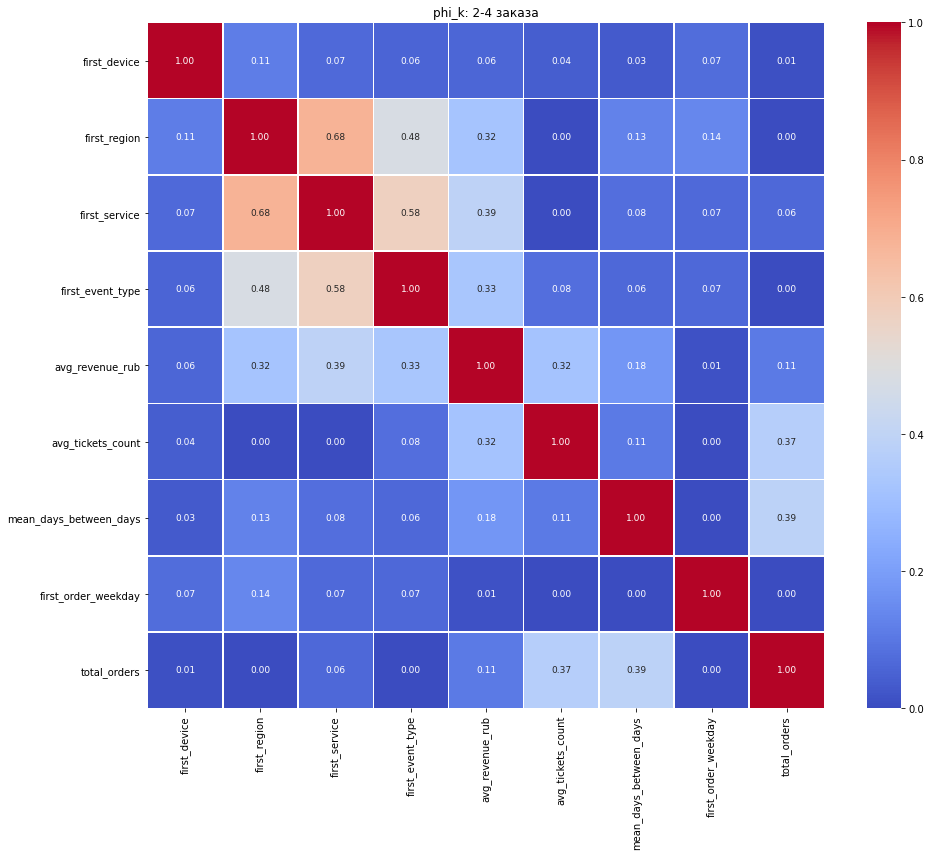

In [77]:
# Тепловая карта для сегмента 2-4 заказа
seg_name = '2-4 заказа'
seg_df = segments[seg_name]
cols_to_use = features.copy()
seg_df_sub = seg_df[cols_to_use + ['total_orders']].dropna()
interval_cols_seg = [col for col in interval_cols if col in cols_to_use]
phi_seg = phik_matrix(seg_df_sub, interval_cols=interval_cols_seg)

plt.figure(figsize=(14, 12))
sns.heatmap(phi_seg, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.2f',
            annot_kws={'size': 9}, linewidths=0.5)
plt.title(f'phi_k: {seg_name}')
plt.tight_layout()
plt.show()

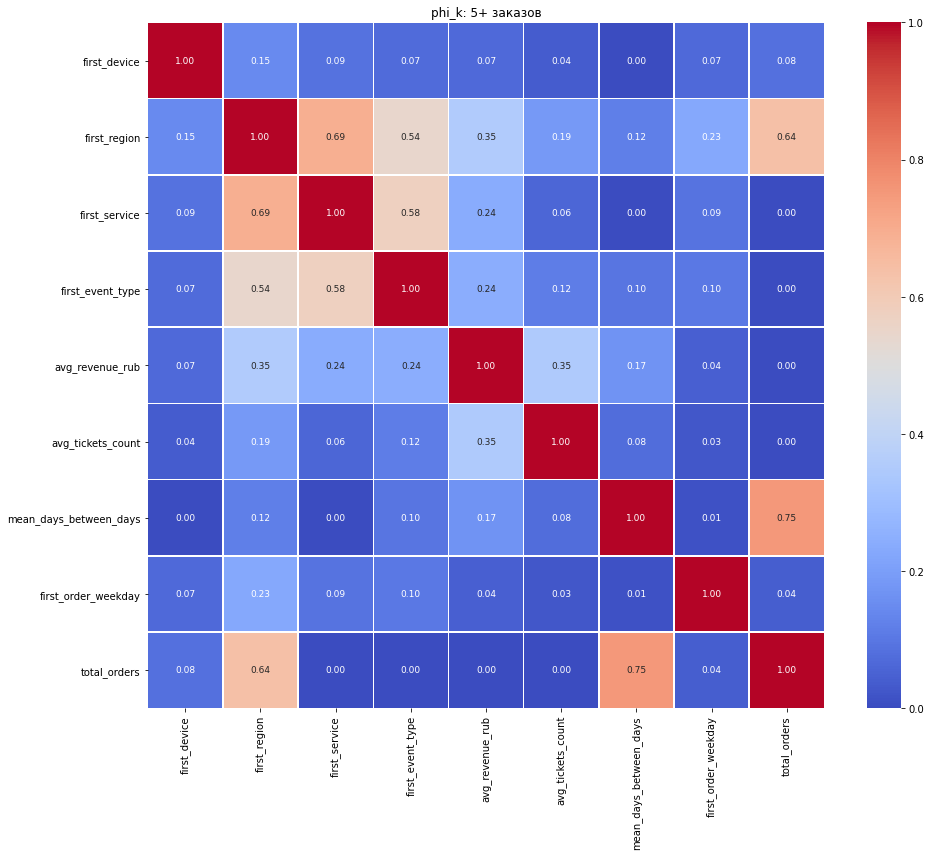

In [78]:
# Тепловая карта для сегмента 5+ заказов
seg_name = '5+ заказов'
seg_df = segments[seg_name]
cols_to_use = features.copy()
seg_df_sub = seg_df[cols_to_use + ['total_orders']].dropna()
interval_cols_seg = [col for col in interval_cols if col in cols_to_use]
phi_seg = phik_matrix(seg_df_sub, interval_cols=interval_cols_seg)

plt.figure(figsize=(14, 12))
sns.heatmap(phi_seg, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.2f',
            annot_kws={'size': 9}, linewidths=0.5)
plt.title(f'phi_k: {seg_name}')
plt.tight_layout()
plt.show()

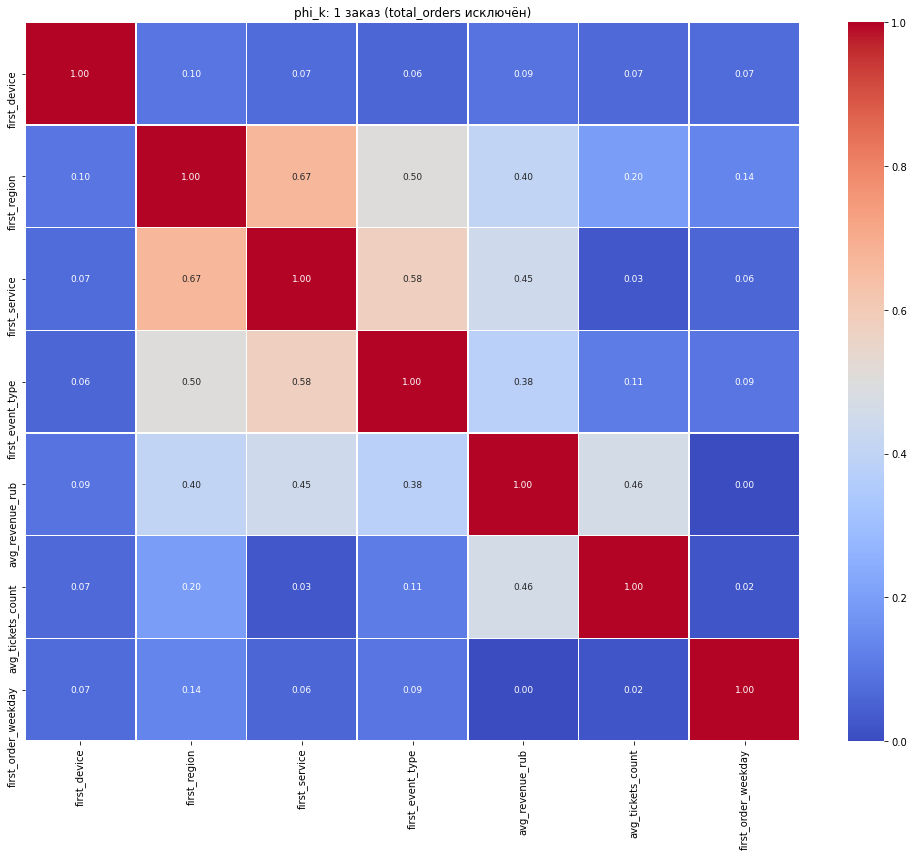

In [79]:
# Тепловая карта для сегмента 1 заказ (без total_orders, т.к. он исключён)
seg_name = '1 заказ'
seg_df = segments[seg_name]
cols_to_use = [col for col in features if col != 'mean_days_between_days']
seg_df_sub = seg_df[cols_to_use].dropna()  # не добавляем total_orders
interval_cols_seg = [col for col in interval_cols if col in cols_to_use]
phi_seg = phik_matrix(seg_df_sub, interval_cols=interval_cols_seg)

plt.figure(figsize=(14, 12))
sns.heatmap(phi_seg, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.2f',
            annot_kws={'size': 9}, linewidths=0.5)
plt.title(f'phi_k: {seg_name} (total_orders исключён)')
plt.tight_layout()
plt.show()

**Краткий вывод**

**Общая корреляция (вся выборка):**
- Наиболее заметная связь с количеством заказов (`total_orders`) наблюдается у двух признаков:
  - **средний интервал между заказами** (mean_days_between_days): φ_k = 0.50,
  - **регион первого заказа** (first_region): φ_k = 0.41.
- Умеренная связь у **среднего числа билетов** (avg_tickets_count, 0.29) и **средней выручки** (avg_revenue_rub, 0.25).
- Остальные признаки (тип устройства, тип мероприятия, билетный оператор, день недели) показали значения близкие к нулю, то есть линейно/монотонно не связаны с числом заказов.

**Корреляции в сегментах по количеству заказов:**
- *Сегмент 1 заказ*: анализ невозможен (нет вариации target), что ожидаемо.
- *Сегмент 2–4 заказа*:
  - Лидируют **средний интервал** (0.39) и **среднее число билетов** (0.37).
  - Средняя выручка (0.11) и билетный оператор (0.06) слабо выражены.
  - Регион, тип мероприятия, устройство, день недели — практически не влияют внутри этой группы.
- *Сегмент 5+ заказов*:
  - Доминируют **средний интервал** (0.75) и **регион первого заказа** (0.64).
  - Вклад всех остальных признаков (тип устройства, день недели, средняя выручка, число билетов, тип мероприятия, оператор) равен нулю или пренебрежимо мал.

**Основные выводы:**
1. **Средний интервал между заказами** — самый сильный и устойчивый предиктор количества заказов: чем меньше интервал, тем больше заказов делает пользователь. Связь проявляется на всех уровнях лояльности.
2. **Регион первой покупки** сильно влияет на общую активность, особенно среди наиболее лояльных пользователей (5+): в некоторых регионах пользователи склонны делать значительно больше заказов.
3. **Среднее количество билетов** важно для предсказания перехода от 2–4 заказов, но теряет значимость для сверхлояльных.
4. **Средняя выручка** имеет умеренную связь в общей выборке и в сегменте 2–4, но не дифференцирует пользователей с 5+ заказами.
5. Признаки первого заказа (тип мероприятия, билетный оператор, устройство, день недели) практически не коррелируют с количеством заказов, что говорит о том, что они не определяют будущую интенсивность покупок напрямую, хотя могут влиять на сам факт возврата (как мы видели ранее в анализе долей).


<div class="alert alert-block alert-success">
<b>Успех:</b> В выводах правильно сделан  явный акцент на том, что поведение клиентов во времени и количество билетов имеют наибольшую важность для повторных покупок
</div>


### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Общий вывод**

**Данные и их подготовка**
- Исходные данные получены из базы данных Яндекс Афиши (схема `afisha`), исключены фильмы и заказы с редких устройств.
- Выручка приведена к рублю: тенге пересчитаны по курсу 2024 года.
- Выбросы в `revenue` отфильтрованы по 99-му перцентилю (удалено 0.97% записей); экстремально активные пользователи (>=152 заказа) удалены (1.01% пользователей).
- Итоговая выборка: **21 634 пользователя**, **287 786 заказов**.

**1. Общая характеристика пользователей**
- Медианное число заказов — 2, среднее — 6.5 (после очистки).
- **61.3%** пользователей совершили 2 и более заказов, **28.3%** — 5 и более.
- Это указывает на высокий базовый уровень возврата, но потенциал для роста удержания ещё есть.

**2. Признаки первого заказа, связанные с возвратом**
- **Тип мероприятия**: наибольшая доля возврата у начавших с «выставок» (64.0%), «театра» (63.4%), «концертов» (61.8%). Спорт и ёлки заметно отстают (~55.8%).
- **Устройство**: пользователи, совершившие первый заказ с десктопа, возвращаются чуть чаще (63.8% против 60.8% с мобильных), хотя основная масса приходит с мобильных (82.8%).
- **Регион**: выделяются Шанырский регион (67.2% возврата), Светополянский округ (65.6%), Широковская область (64.5%). Крупнейший Каменевский регион (32.7% базы) показывает 62.4% — чуть выше среднего.
- **Билетный оператор**: лидеры по возврату — «Край билетов» (65.2%), «Дом культуры» (64.6%). Массовые операторы держатся около среднего.

**3. Влияние средней выручки и количества билетов**
- **Средняя выручка**: пользователи, совершившие 2 и более заказов, имеют медианную выручку с заказа **495.68 руб.** (против 378.03 руб. у одноразовых). В группе 5+ заказов медиана немного выше, чем в группе 2–4 (512.50 руб. против 471.27 руб.).
- **Количество билетов**: самый высокий уровень повторных заказов у сегмента «2–3 билета в среднем» — **73.6%**. Сегменты «1–2 билета» (51.3%) и «5+ билетов» (18.8%) показывают низкую лояльность.

**4. Временные характеристики и удержание**
- **День недели первой покупки** практически не влияет на долю возврата (разброс 59.4%–63.0%).
- **Средний интервал между заказами**: ключевой фактор. В группе 2–4 заказов он составляет 21.3 дня (медиана 9 дней), в группе 5+ заказов — 9.6 дня (медиана 8 дней). Чем меньше интервал, тем выше общее число заказов.

**5. Корреляционный анализ (phi_k)**
- **Наиболее сильные связи с количеством заказов**:
  - Средний интервал между заказами (φ_k = 0.50–0.75).
  - Регион первого заказа (φ_k = 0.41–0.64).
- Умеренно связаны среднее количество билетов и средняя выручка (0.25–0.37), но для сверхлояльных пользователей их значимость падает.
- Признаки первого заказа (тип мероприятия, оператор, устройство, день недели) на прямую не коррелируют с числом заказов, однако влияют на сам факт повторной покупки (возврат).

**Рекомендации**
1. **Сфокусироваться на успешных «точках входа»**: удерживать пользователей, начинающих с выставок, театра, концертов, а также пришедших через десктоп. Разработать для них программы лояльности, раннее вовлечение.
2. **Работать с регионами**: усилить маркетинг в регионах с низкой долей возврата (Озернинский край, Малиновоярский округ) и тиражировать практики из регионов-лидеров (Шанырский, Светополянский, Широковская обл.).
3. **Стимулировать сокращение интервала между покупками**: внедрить персонализированные напоминания, акции «вернись через N дней», специальные предложения после первого заказа, чтобы уменьшить время до повторной покупки.
4. **Поощрять покупку 2–3 билетов**: Возможно, предлагать скидки при покупке второго билета.
5. **Не вкладываться в оптимизацию по дню недели**: он не влияет на возврат, ресурсы лучше направить на более значимые факторы.
6. **Использовать средний интервал как предиктор**: для построения модели прогнозирования числа заказов, что позволит проактивно удерживать клиентов с растущим интервалом.



<div class="alert alert-block alert-success">
<b>Успех:</b> Всегда приятно наблюдать подробный и структурированный итоговый вывод в конце работы!
</div>




### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

In [80]:
# Создание файла .gitignore в корне проекта
gitignore_content = """\
# Чувствительные данные
.env

# Временные файлы и кэш
__pycache__/
*.py[cod]
.ipynb_checkpoints/

# Файлы данных
*.csv

# Системные файлы
.DS_Store
Thumbs.db
"""

with open('.gitignore', 'w') as f:
    f.write(gitignore_content)
print("Файл .gitignore создан.")

Файл .gitignore создан.


In [81]:
# Генерация списка зависимостей и запись в requirements.txt
# Перечислим библиотеки, которые использовали в проекте
required_packages = [
    'pandas',
    'sqlalchemy',
    'psycopg2-binary',
    'phik',
    'matplotlib',
    'seaborn',
    'python-dotenv'
]

with open('requirements.txt', 'w') as f:
    for pkg in required_packages:
        # Определяем установленную версию
        try:
            version = __import__(pkg.replace('-', '_')).__version__
        except:
            version = 'unknown'
        f.write(f"{pkg}=={version}\n")

print("Файл requirements.txt создан.")

Файл requirements.txt создан.


In [82]:
# Установка библиотеки python-dotenv
!pip install python-dotenv

In [83]:
# Создание файла .env с параметрами подключения
env_content = """\
DB_USER=praktikum_student
DB_PWD=Sdf4$2;d-d30pp
DB_HOST=rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net
DB_PORT=6432
DB_NAME=data-analyst-afisha
"""

with open('.env', 'w') as f:
    f.write(env_content)

print("Файл .env создан. Он добавлен в .gitignore, в репозиторий не попадёт.")

Файл .env создан. Он добавлен в .gitignore, в репозиторий не попадёт.


In [84]:
# Создание примера .env.example (без реальных паролей) для информации
example_content = """\
DB_USER=your_user
DB_PWD=your_password
DB_HOST=your_host
DB_PORT=6432
DB_NAME=your_db
"""

with open('.env.example', 'w') as f:
    f.write(example_content)

print("Файл .env.example создан.")

Файл .env.example создан.


In [85]:
# Модифицируем ячейку с параметрами подключения для чтения из переменных окружения
import os
from dotenv import load_dotenv

# Загрузка переменных из .env
load_dotenv()

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PWD'),
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT')),
    'db': os.getenv('DB_NAME')
}

print("Конфигурация загружена из переменных окружения.")
# Далее используем db_config как и раньше

Конфигурация загружена из переменных окружения.


**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**
https://github.com/evgeniypetrov1001/yandex_afisha


 <div class="alert alert-block alert-danger">
    
<b>Ошибка:</b>    чувствительные данные (параметры подключения) заливать  на гитхаб нельзя.

</div>




<div class="alert alert-block alert-info">
<b>Совет:</b>  Неплохо было бы еще добавить README.md - это общая практика
    
</div>
